In [2]:
%pip install -q pandas matplotlib 'pydantic>=2' ipywidgets

Note: you may need to restart the kernel to use updated packages.


In [3]:
from __future__ import annotations
import copy, html, importlib.metadata, json, os, re, sys, time
from datetime import date, timedelta, datetime, timezone
from decimal import Decimal, ROUND_HALF_UP
from typing import Any, Literal
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import HTML, display
from pydantic import BaseModel, ConfigDict, Field, StrictBool, ValidationError, field_validator, model_validator

CENT = Decimal('0.01')
os.environ.setdefault('TRAVEL_AGENT_LLM_MODE', 'offline')
os.environ.setdefault('OLLAMA_BASE_URL', 'http://localhost:11434')
os.environ.setdefault('OLLAMA_MODEL', 'qwen2.5:3b')

def money(value: Any) -> Decimal:
    amount = Decimal(str(value))
    if not amount.is_finite(): raise ValueError('Money must be finite')
    return amount.quantize(CENT, rounding=ROUND_HALF_UP)

def usd(value: Any) -> str: return f'${money(value):,.2f}'

POLICIES = {
 'POL-CAT-01': {'topic':'eligible categories','text':'Eligible: economy airfare, lodging, meals, ground transport and conference fees for a documented business purpose.'},
 'POL-CAT-02': {'topic':'ineligible categories','text':'Never reimbursable: alcohol, minibar, spa, gym, personal entertainment, shopping, gifts, fines, penalties, late fees and personal expenses.'},
 'POL-PD-01': {'topic':'meal limit','text':'Meals are capped at $75 per day; excess is deducted.','limit':75},
 'POL-PD-02': {'topic':'lodging limit','text':'Lodging is capped at $200 per night; excess is deducted.','limit':200},
 'POL-PD-03': {'topic':'ground transport limit','text':'Ground transport is capped at $50 per day; excess is deducted.','limit':50},
 'POL-AIR-01': {'topic':'airfare class','text':'Only economy airfare is automatically reimbursable. Business or first class requires Manual Review.'},
 'POL-RCT-01': {'topic':'receipt required','text':'Any line item above $25 requires an itemized receipt. Airfare and lodging always require receipts.'},
 'POL-RCT-02': {'topic':'missing receipt','text':'A missing required receipt routes the claim to Manual Review.'},
 'POL-APR-01': {'topic':'auto approve','text':'A compliant reimbursable total at or below $500 may be auto-approved.'},
 'POL-APR-02': {'topic':'manager tier','text':'A compliant total above $500 and at or below $2,000 is approvable.'},
 'POL-APR-03': {'topic':'director tier','text':'A reimbursable total above $2,000 requires Manual Review.'},
 'POL-TIME-01': {'topic':'submission timeliness','text':'Claims submitted more than 30 days after the expense date require Manual Review.'}}
ELIGIBLE = {'airfare','lodging','meals','ground_transport','conference_fees'}
INELIGIBLE = {'alcohol','minibar','spa','gym','personal_entertainment','in_room_movies','personal_shopping','gifts','traffic_fines','penalties','late_fees','personal'}
CAPS = {'meals':(money(75),'POL-PD-01'),'lodging':(money(200),'POL-PD-02'),'ground_transport':(money(50),'POL-PD-03')}

class ExpenseItem(BaseModel):
    model_config = ConfigDict(extra='forbid', str_strip_whitespace=True)
    category: str = Field(min_length=1, max_length=80)
    description: str = Field(min_length=1, max_length=1000)
    amount: Decimal = Field(gt=0, max_digits=12, decimal_places=2, allow_inf_nan=False)
    receipt_attached: StrictBool
    units: int = Field(default=1, ge=1, le=366, strict=True)
    expense_date: date | None = None
    travel_class: str | None = None
    @field_validator('amount', mode='before')
    @classmethod
    def reject_bool(cls, value):
        if isinstance(value, bool): raise ValueError('Boolean values are not monetary amounts')
        return value
    @field_validator('category')
    @classmethod
    def normalize_category(cls, value):
        value = re.sub(r'[^a-z0-9]+','_',value.lower()).strip('_')
        if not value: raise ValueError('A category name is required')
        return value
    @field_validator('travel_class')
    @classmethod
    def normalize_class(cls, value): return value.lower().strip().replace('_',' ') if value else None

class ClaimInput(BaseModel):
    model_config = ConfigDict(extra='forbid', str_strip_whitespace=True)
    claim_id: str = Field(pattern=r'^[A-Za-z0-9_-]{1,80}$')
    employee: str = Field(min_length=1, max_length=160)
    business_purpose: str = Field(default='', max_length=1000)
    trip_start: date
    trip_end: date
    submitted: date
    items: list[ExpenseItem] = Field(min_length=1, max_length=100)
    @model_validator(mode='after')
    def timeline(self):
        if self.trip_end < self.trip_start: raise ValueError('trip_end cannot be before trip_start')
        if self.submitted < self.trip_end: raise ValueError('submitted cannot be before trip_end')
        if any(x.expense_date and x.expense_date > self.submitted for x in self.items): raise ValueError('expense_date cannot be after submission')
        return self
    @property
    def claimed_total(self): return sum((x.amount for x in self.items), money(0))

Decision = Literal['APPROVE','PARTIAL_APPROVE','REJECT','MANUAL_REVIEW']
class ClaimResult(BaseModel):
    model_config = ConfigDict(extra='forbid', allow_inf_nan=False)
    claim_id: str; decision: Decision; approved_amount: float = Field(ge=0); deducted_amount: float = Field(ge=0)
    missing_docs: list[str]; policy_refs: list[str]; confidence: float = Field(ge=0, le=1); explanation: str = Field(min_length=1); tools_used: list[str] = Field(min_length=2)
    @field_validator('approved_amount','deducted_amount')
    @classmethod
    def exact_cents(cls, value):
        if Decimal(str(value)) != money(value): raise ValueError('Output amounts must have no sub-cent precision')
        return value
    @field_validator('policy_refs')
    @classmethod
    def known_refs(cls, value):
        if set(value) - set(POLICIES): raise ValueError('Unknown policy identifier')
        return sorted(set(value))

print('Python:', sys.version.split()[0])
print('Dependencies:', ', '.join(f'{p} {importlib.metadata.version(p)}' for p in ('pydantic','pandas','matplotlib')))
display(pd.DataFrame([{'policy_id':k,'topic':v['topic'],'rule':v['text']} for k,v in POLICIES.items()]))

Python: 3.14.2
Dependencies: pydantic 2.13.5, pandas 3.0.6, matplotlib 3.11.2


,policy_id,topic,rule
0,POL-CAT-01,eligible categories,"Eligible: economy airfare, lodging, meals, gro..."
1,POL-CAT-02,ineligible categories,"Never reimbursable: alcohol, minibar, spa, gym..."
2,POL-PD-01,meal limit,Meals are capped at $75 per day; excess is ded...
3,POL-PD-02,lodging limit,Lodging is capped at $200 per night; excess is...
4,POL-PD-03,ground transport limit,Ground transport is capped at $50 per day; exc...
5,POL-AIR-01,airfare class,Only economy airfare is automatically reimburs...
6,POL-RCT-01,receipt required,Any line item above $25 requires an itemized r...
7,POL-RCT-02,missing receipt,A missing required receipt routes the claim to...
8,POL-APR-01,auto approve,A compliant reimbursable total at or below $50...
9,POL-APR-02,manager tier,A compliant total above $500 and at or below $...


In [4]:
RAW_CLAIMS = [
 {'claim_id':'CLM-001','employee':'A. Rivera','business_purpose':'Attend 2-day industry conference','trip_start':'2026-06-10','trip_end':'2026-06-12','submitted':'2026-06-20','items':[{'category':'airfare','description':'Round-trip economy airfare','amount':420,'receipt_attached':True,'travel_class':'economy'},{'category':'lodging','description':'Hotel, 2 nights @ $180','amount':360,'receipt_attached':True,'units':2},{'category':'meals','description':'Meals, 3 days @ ~$60/day','amount':180,'receipt_attached':True,'units':3},{'category':'conference_fees','description':'Conference registration','amount':150,'receipt_attached':True}]},
 {'claim_id':'CLM-002','employee':'B. Osei','business_purpose':'Weekend hotel stay','trip_start':'2026-06-14','trip_end':'2026-06-15','submitted':'2026-06-25','items':[{'category':'spa','description':'Hotel spa package','amount':300,'receipt_attached':True},{'category':'minibar','description':'In-room minibar','amount':80,'receipt_attached':True}]},
 {'claim_id':'CLM-003','employee':'C. Nakamura','business_purpose':'Client site visit','trip_start':'2026-06-08','trip_end':'2026-06-10','submitted':'2026-06-22','items':[{'category':'airfare','description':'Round-trip economy airfare','amount':300,'receipt_attached':True,'travel_class':'economy'},{'category':'lodging','description':'Hotel, 2 nights @ $250','amount':500,'receipt_attached':True,'units':2},{'category':'meals','description':'Meals, 2 days @ $70/day','amount':140,'receipt_attached':True,'units':2}]},
 {'claim_id':'CLM-004','employee':'D. Fischer','business_purpose':'International vendor negotiation','trip_start':'2026-06-16','trip_end':'2026-06-18','submitted':'2026-06-28','items':[{'category':'airfare','description':'Business-class international airfare','amount':2400,'receipt_attached':True,'travel_class':'business'},{'category':'lodging','description':'Hotel, 3 nights','amount':600,'receipt_attached':False,'units':3}]},
 {'claim_id':'CLM-005','employee':'E. Haddad','business_purpose':'Client dinner / business development','trip_start':'2026-06-11','trip_end':'2026-06-11','submitted':'2026-06-24','items':[{'category':'meals','description':'Client dinner for 4 (business development)','amount':220,'receipt_attached':False,'units':1}]},]
CLAIMS = [ClaimInput.model_validate(x) for x in RAW_CLAIMS]
assert [x.claim_id for x in CLAIMS] == [f'CLM-{i:03d}' for i in range(1,6)]
display(pd.DataFrame([{'claim_id':x.claim_id,'employee':x.employee,'claimed_amount':float(x.claimed_total)} for x in CLAIMS]))

def policy_lookup(claim):
    refs = {'POL-CAT-01','POL-CAT-02','POL-RCT-01','POL-RCT-02','POL-APR-01','POL-APR-02','POL-APR-03','POL-TIME-01'}
    for item in claim.items:
        if item.category in CAPS: refs.add(CAPS[item.category][1])
        if item.category == 'airfare': refs.add('POL-AIR-01')
    return {'policy_refs':sorted(refs),'context':{x:POLICIES[x]['text'] for x in sorted(refs)}}

def eligibility_checker(claim):
    eligible, ineligible, unknown = [], [], []
    for i,item in enumerate(claim.items):
        (eligible if item.category in ELIGIBLE else ineligible if item.category in INELIGIBLE else unknown).append(i)
    refs = (['POL-CAT-01'] if eligible else []) + (['POL-CAT-02'] if ineligible else [])
    if unknown: refs += ['POL-CAT-01','POL-CAT-02']
    return {'eligible_indices':eligible,'ineligible_indices':ineligible,'unknown_indices':unknown,'purpose_missing':not bool(claim.business_purpose),'policy_refs':sorted(set(refs))}

def receipt_checker(claim):
    missing=[]; required=[]
    for i,item in enumerate(claim.items):
        if item.amount > money(25) or item.category in {'airfare','lodging'}:
            required.append(i)
            if not item.receipt_attached: missing.append(f'Item {i+1}: itemized receipt for {item.category}')
    return {'required_indices':required,'missing_docs':missing,'policy_refs':(['POL-RCT-1'] if False else (['POL-RCT-01'] if required else []))+(['POL-RCT-02'] if missing else [])}

def airfare_status(item):
    text=item.description.lower(); economy=bool(re.search(r'\b(economy|coach)\b',text)); exception=bool(re.search(r'\b(business[ -]class|first[ -]class|premium[ -]economy)\b',text))
    if item.travel_class in {'economy','coach'}: return 'conflicting' if exception else 'economy'
    if item.travel_class: return 'conflicting' if economy and not exception else 'exception'
    if economy and not exception: return 'economy'
    if exception: return 'exception'
    return 'unknown'

def metadata_checker(claim):
    issues=[]; docs=[]; blocked=set(); days=(claim.trip_end-claim.trip_start).days+1; nights=(claim.trip_end-claim.trip_start).days
    for i,item in enumerate(claim.items):
        if item.category not in CAPS: continue
        allowed=nights if item.category=='lodging' else days
        if item.units > allowed: issues.append(f'Item {i+1}: {item.units} {item.category} units conflict with trip dates'); docs.append(f'Item {i+1}: dates supporting claimed {item.category} units')
        if item.expense_date and item.units != 1: issues.append(f'Item {i+1}: a single expense_date cannot describe multiple capped units'); docs.append(f'Item {i+1}: dated breakdown of units'); blocked.add(i)
        if item.expense_date and not (claim.trip_start <= item.expense_date <= claim.trip_end): issues.append(f'Item {i+1}: capped expense date is outside the trip'); docs.append(f'Item {i+1}: corrected expense or trip dates'); blocked.add(i)
    return {'issues':issues,'missing_docs':docs,'blocked_indices':sorted(blocked),'policy_refs':[]}

def limit_checker(claim):
    blocked=set(metadata_checker(claim)['blocked_indices']); details=[]; exceptions=[]; docs=[]; eligible_total=deducted_total=pending_total=money(0)
    for i,item in enumerate(claim.items):
        cat, amount=item.category,item.amount; eligible=deducted=pending=money(0); ref=None
        if cat in INELIGIBLE: deducted,ref=amount,'POL-CAT-02'
        elif cat not in ELIGIBLE: pending=amount; exceptions.append(f'Item {i+1}: category is not covered by supplied policy'); docs.append(f'Item {i+1}: category eligibility clarification')
        elif cat=='airfare' and airfare_status(item)!='economy': pending=amount; ref='POL-AIR-01'; exceptions.append(f'Item {i+1}: airfare class is {airfare_status(item)}; verify class/pre-approval'); docs.append(f'Item {i+1}: airfare class/pre-approval evidence')
        elif i in blocked: pending=amount; ref=CAPS[cat][1]
        elif cat in CAPS:
            cap,ref=CAPS[cat]; cap *= item.units; eligible=min(amount,cap); deducted=max(money(0),amount-cap)
        else: eligible=amount; ref='POL-CAT-01'
        eligible_total+=eligible; deducted_total+=deducted; pending_total+=pending
        details.append({'indices':[i],'category':cat,'claimed':float(amount),'eligible':float(eligible),'deducted':float(deducted),'pending':float(pending),'policy_ref':ref})
    return {'items':details,'eligible':float(eligible_total),'deducted':float(deducted_total),'pending':float(pending_total),'exceptions':exceptions,'missing_docs':docs,'policy_refs':sorted({x['policy_ref'] for x in details if x['policy_ref']})}

def timeliness_checker(claim):
    checks=[]
    for i,item in enumerate(claim.items):
        earliest=latest=(claim.submitted-item.expense_date).days if item.expense_date else (claim.submitted-claim.trip_end).days
        if not item.expense_date: latest=(claim.submitted-claim.trip_start).days
        checks.append({'index':i,'min_days':earliest,'max_days':latest,'status':'LATE' if earliest>30 else 'UNCERTAIN' if latest>30 else 'WITHIN_WINDOW'})
    return {'items':checks,'late':any(x['status']=='LATE' for x in checks),'uncertain':any(x['status']=='UNCERTAIN' for x in checks),'policy_refs':['POL-TIME-01']}

def duplicate_detector(claim,batch):
    fp=lambda c:(c.employee.casefold(),c.trip_start,c.trip_end,c.claimed_total)
    return {'possible_duplicates':[x.claim_id for x in batch if x.claim_id!=claim.claim_id and fp(x)==fp(claim)],'policy_refs':[]}

def approval_threshold_checker(amount):
    amount=money(amount); tier='AUTO' if amount<=500 else 'MANAGER' if amount<=2000 else 'DIRECTOR'; return {'tier':tier,'manual_review':tier=='DIRECTOR','threshold_basis':float(amount),'policy_refs':[{'AUTO':'POL-APR-01','MANAGER':'POL-APR-02','DIRECTOR':'POL-APR-03'}[tier]]}

TOOLS={'eligibility_checker':eligibility_checker,'receipt_checker':receipt_checker,'limit_checker':limit_checker,'timeliness_checker':timeliness_checker,'metadata_checker':metadata_checker,'duplicate_detector':duplicate_detector}
REQUIRED_TOOLS=list(TOOLS)

,claim_id,employee,claimed_amount
0,CLM-001,A. Rivera,1110.0
1,CLM-002,B. Osei,380.0
2,CLM-003,C. Nakamura,940.0
3,CLM-004,D. Fischer,3000.0
4,CLM-005,E. Haddad,220.0


In [5]:
def evaluate_claim(claim, all_claims=None):
    claim=ClaimInput.model_validate(claim); batch=[ClaimInput.model_validate(x) for x in (all_claims or [claim])]
    if len({x.claim_id for x in batch}) != len(batch): raise ValueError('Duplicate claim_id in batch')
    policy=policy_lookup(claim); evidence={name:(duplicate_detector(claim,batch) if name=='duplicate_detector' else fn(claim)) for name,fn in TOOLS.items()}
    limits, eligibility, receipts = evidence['limit_checker'], evidence['eligibility_checker'], evidence['receipt_checker']
    metadata, timing, duplicates = evidence['metadata_checker'], evidence['timeliness_checker'], evidence['duplicate_detector']
    threshold=approval_threshold_checker(money(limits['eligible'])+money(limits['pending'])); evidence['approval_threshold_checker']=threshold
    approved,deducted,pending=(money(limits[x]) for x in ('eligible','deducted','pending')); missing=receipts['missing_docs']+limits['missing_docs']+metadata['missing_docs']; reasons=[]
    if receipts['missing_docs']: reasons.append('required receipts are missing')
    if eligibility['purpose_missing']: reasons.append('documented business purpose is missing'); missing.append('Documented business purpose')
    if eligibility['unknown_indices']: reasons.append('a category is not covered by policy')
    reasons.extend(limits['exceptions']+metadata['issues'])
    if timing['late']: reasons.append('an expense is more than 30 days old at submission')
    if timing['uncertain']: reasons.append('actual expense dates are needed to verify the 30-day window'); missing.append('Actual expense dates')
    if duplicates['possible_duplicates']: reasons.append('a possible duplicate requires verification')
    if threshold['manual_review']: reasons.append('potential reimbursement exceeds $2,000 and requires director review')
    if reasons:
        decision='MANUAL_REVIEW'; explanation=f'Manual review: {"; ".join(dict.fromkeys(reasons))}. {usd(approved)} is provisionally eligible, {usd(deducted)} is deducted, and {usd(pending)} remains unresolved. No payment is authorized until review is complete.'
    elif approved==0 and deducted==claim.claimed_total:
        decision='REJECT'; explanation=f'All items are ineligible under POL-CAT-02; the full {usd(deducted)} is deducted.'
    elif deducted:
        decision='PARTIAL_APPROVE'; explanation=f'Recommend {usd(approved)} reimbursement and deduct {usd(deducted)} for ineligible items and/or amounts above policy caps.'
    else:
        decision='APPROVE'; explanation=f'All required policy checks are satisfied. Recommend {usd(approved)} reimbursement within the {threshold["tier"].lower()} approval tier.'
    refs=sorted({ref for check in evidence.values() for ref in check.get('policy_refs',[])})
    if decision=='REJECT': refs=['POL-CAT-02']
    financials={'claimed_amount':float(claim.claimed_total),'provisional_eligible':float(approved),'deducted_amount':float(deducted),'pending_review_amount':float(pending),'recommendation_amount':float(approved) if decision in {'APPROVE','PARTIAL_APPROVE'} else 0.0,'reconciled':approved+deducted+pending==claim.claimed_total}
    if not financials['reconciled']: raise ValueError('Monetary conservation failed')
    result=ClaimResult(claim_id=claim.claim_id,decision=decision,approved_amount=float(approved),deducted_amount=float(deducted),missing_docs=sorted(set(missing)),policy_refs=refs,confidence=0.85 if reasons else 0.99,explanation=explanation,tools_used=['policy_lookup']+REQUIRED_TOOLS+['approval_threshold_checker','output_validator'])
    audit={'claim_id':claim.claim_id,'provider':'offline_rules','model':'none','plan':{'tools':REQUIRED_TOOLS,'proposed_tools':REQUIRED_TOOLS,'guard_added':[],'live_plan':False,'reason':'Offline mode executes every required policy check.'},'review_status':'not_run','policy_context':policy['context'],'tool_outputs':evidence,'financials':financials,'elapsed_seconds':0.0}
    return result,audit

def evaluate_batch(claims):
    batch=[ClaimInput.model_validate(x) for x in claims]
    return zip(*[evaluate_claim(x,batch) for x in batch])

RESULT_MODELS,AUDIT_TRAIL=evaluate_batch(CLAIMS)
RESULT_MODELS=list(RESULT_MODELS); AUDIT_TRAIL=list(AUDIT_TRAIL)
RESULTS=[x.model_dump(mode='json') for x in RESULT_MODELS]
display(pd.DataFrame([{k:r[k] for k in ('claim_id','decision','approved_amount','deducted_amount','confidence')} for r in RESULTS]))
for r in RESULTS: print(r['claim_id'],r['decision'],'-',r['explanation'])

,claim_id,decision,approved_amount,deducted_amount,confidence
0,CLM-001,APPROVE,1110.0,0.0,0.99
1,CLM-002,REJECT,0.0,380.0,0.99
2,CLM-003,PARTIAL_APPROVE,840.0,100.0,0.99
3,CLM-004,MANUAL_REVIEW,600.0,0.0,0.85
4,CLM-005,MANUAL_REVIEW,75.0,145.0,0.85


CLM-001 APPROVE - All required policy checks are satisfied. Recommend $1,110.00 reimbursement within the manager approval tier.
CLM-002 REJECT - All items are ineligible under POL-CAT-02; the full $380.00 is deducted.
CLM-003 PARTIAL_APPROVE - Recommend $840.00 reimbursement and deduct $100.00 for ineligible items and/or amounts above policy caps.
CLM-004 MANUAL_REVIEW - Manual review: required receipts are missing; Item 1: airfare class is exception; verify class/pre-approval; Item 2: 3 lodging units conflict with trip dates; potential reimbursement exceeds $2,000 and requires director review. $600.00 is provisionally eligible, $0.00 is deducted, and $2,400.00 remains unresolved. No payment is authorized until review is complete.
CLM-005 MANUAL_REVIEW - Manual review: required receipts are missing. $75.00 is provisionally eligible, $145.00 is deducted, and $0.00 remains unresolved. No payment is authorized until review is complete.


,claim_id,decision,claimed,eligible (provisional),deducted,unresolved,recommended now
0,CLM-001,APPROVE,"$1,110.00","$1,110.00",$0.00,$0.00,"$1,110.00"
1,CLM-002,REJECT,$380.00,$0.00,$380.00,$0.00,$0.00
2,CLM-003,PARTIAL_APPROVE,$940.00,$840.00,$100.00,$0.00,$840.00
3,CLM-004,MANUAL_REVIEW,"$3,000.00",$600.00,$0.00,"$2,400.00",$0.00
4,CLM-005,MANUAL_REVIEW,$220.00,$75.00,$145.00,$0.00,$0.00


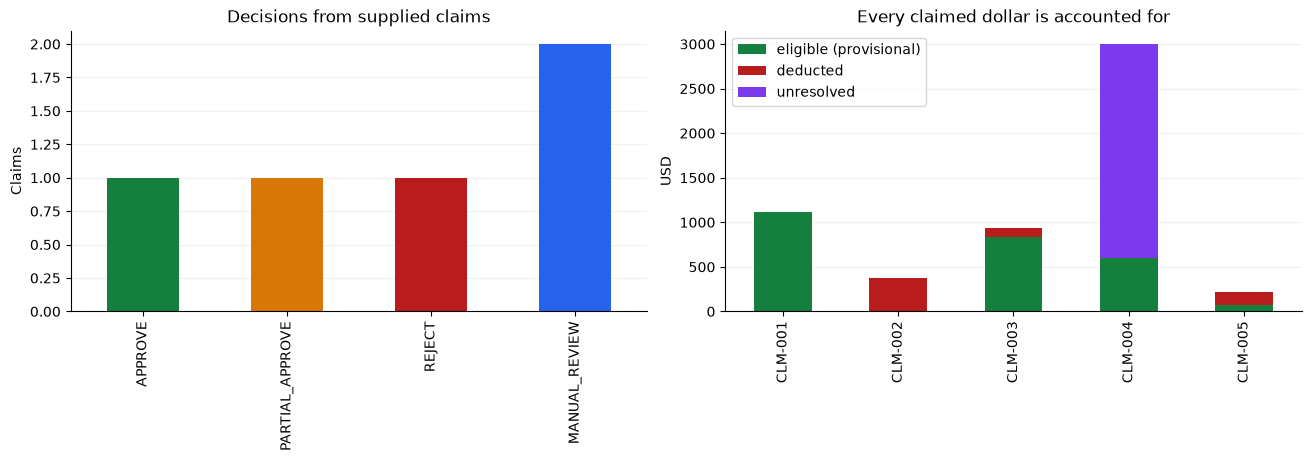

,indices,category,claimed,eligible,deducted,pending,policy_ref
0,[0],airfare,420.0,420.0,0.0,0.0,POL-CAT-01
1,[1],lodging,360.0,360.0,0.0,0.0,POL-PD-02
2,[2],meals,180.0,180.0,0.0,0.0,POL-PD-01
3,[3],conference_fees,150.0,150.0,0.0,0.0,POL-CAT-01


Missing documents: None
Policies: POL-APR-02, POL-CAT-01, POL-PD-01, POL-PD-02, POL-RCT-01, POL-TIME-01
Regression checks passed: 5 claim golden checks plus threshold and receipt boundaries.
All monetary totals reconciled: True
Live model: False (set TRAVEL_AGENT_LLM_MODE=ollama or azure to add a provider adapter)


In [6]:
dashboard_df=pd.DataFrame([{'claim_id':a['claim_id'],'decision':RESULTS[i]['decision'],'claimed':a['financials']['claimed_amount'],'eligible (provisional)':a['financials']['provisional_eligible'],'deducted':a['financials']['deducted_amount'],'unresolved':a['financials']['pending_review_amount'],'recommended now':a['financials']['recommendation_amount']} for i,a in enumerate(AUDIT_TRAIL)])
counts=dashboard_df.decision.value_counts()
display(HTML(f'<b>Travel reimbursement review</b><br>{len(RESULTS)} claims | {usd(dashboard_df.claimed.sum())} claimed | {int(counts.get("MANUAL_REVIEW",0))} need a reviewer<br><small>Manual-review amounts are provisional; this prototype never executes payment.</small>'))
formatted=dashboard_df.copy()
for col in formatted.columns[2:]: formatted[col]=formatted[col].map(usd)
display(formatted)
fig,axes=plt.subplots(1,2,figsize=(13,4.5),layout='constrained')
counts.reindex(['APPROVE','PARTIAL_APPROVE','REJECT','MANUAL_REVIEW'],fill_value=0).plot.bar(ax=axes[0],color=['#15803d','#d97706','#b91c1c','#2563eb'])
axes[0].set(title='Decisions from supplied claims',ylabel='Claims',xlabel='')
dashboard_df.set_index('claim_id')[['eligible (provisional)','deducted','unresolved']].plot.bar(stacked=True,ax=axes[1],color=['#15803d','#b91c1c','#7c3aed'])
axes[1].set(title='Every claimed dollar is accounted for',ylabel='USD',xlabel='')
for ax in axes: ax.grid(axis='y',alpha=.18); ax.set_axisbelow(True); ax.spines[['top','right']].set_visible(False)
plt.show()

def render_claim_details(claim_id):
    i=next(i for i,r in enumerate(RESULTS) if r['claim_id']==claim_id); result=RESULTS[i]; audit=AUDIT_TRAIL[i]
    display(HTML(f'<h3>{html.escape(claim_id)}: {html.escape(result["decision"])}</h3><p>{html.escape(result["explanation"])}</p>'))
    display(pd.DataFrame(audit['tool_outputs']['limit_checker']['items']))
    print('Missing documents:',', '.join(result['missing_docs']) or 'None'); print('Policies:',', '.join(result['policy_refs']))
render_claim_details('CLM-001')

EXPECTED={'CLM-001':('APPROVE',1110,0,0),'CLM-002':('REJECT',0,380,0),'CLM-003':('PARTIAL_APPROVE',840,100,0),'CLM-004':('MANUAL_REVIEW',600,0,2400),'CLM-005':('MANUAL_REVIEW',75,145,0)}
assert len(RESULTS)==5
for result,audit in zip(RESULTS,AUDIT_TRAIL):
    expected=EXPECTED[result['claim_id']]
    assert (result['decision'],result['approved_amount'],result['deducted_amount'],audit['financials']['pending_review_amount'])==expected
    assert set(result)=={'claim_id','decision','approved_amount','deducted_amount','missing_docs','policy_refs','confidence','explanation','tools_used'}
assert approval_threshold_checker(500)['tier']=='AUTO' and approval_threshold_checker(500.01)['tier']=='MANAGER'
assert approval_threshold_checker(2000.01)['tier']=='DIRECTOR'
assert not receipt_checker(ClaimInput.model_validate({**RAW_CLAIMS[4],'items':[dict(RAW_CLAIMS[4]['items'][0],amount=25,receipt_attached=False)]}))['missing_docs']
print('Regression checks passed:',len(RESULTS),'claim golden checks plus threshold and receipt boundaries.')
print('All monetary totals reconciled:',all(x['financials']['reconciled'] for x in AUDIT_TRAIL))
print('Live model:',False,'(set TRAVEL_AGENT_LLM_MODE=ollama or azure to add a provider adapter)')

In [7]:
FINAL_RESULTS=[ClaimResult.model_validate(row).model_dump(mode='json') for row in RESULTS]
assert len(FINAL_RESULTS)==5 and all(set(row)=={'claim_id','decision','approved_amount','deducted_amount','missing_docs','policy_refs','confidence','explanation','tools_used'} for row in FINAL_RESULTS)
print(json.dumps(FINAL_RESULTS,indent=2,allow_nan=False))

[
  {
    "claim_id": "CLM-001",
    "decision": "APPROVE",
    "approved_amount": 1110.0,
    "deducted_amount": 0.0,
    "missing_docs": [],
    "policy_refs": [
      "POL-APR-02",
      "POL-CAT-01",
      "POL-PD-01",
      "POL-PD-02",
      "POL-RCT-01",
      "POL-TIME-01"
    ],
    "confidence": 0.99,
    "explanation": "All required policy checks are satisfied. Recommend $1,110.00 reimbursement within the manager approval tier.",
    "tools_used": [
      "policy_lookup",
      "eligibility_checker",
      "receipt_checker",
      "limit_checker",
      "timeliness_checker",
      "metadata_checker",
      "duplicate_detector",
      "approval_threshold_checker",
      "output_validator"
    ]
  },
  {
    "claim_id": "CLM-002",
    "decision": "REJECT",
    "approved_amount": 0.0,
    "deducted_amount": 380.0,
    "missing_docs": [],
    "policy_refs": [
      "POL-CAT-02"
    ],
    "confidence": 0.99,
    "explanation": "All items are ineligible under POL-CAT-02; the full